In [ ]:
import pandas as pd
import os
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATASET_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../genes.csv"
GEADIENT_GENES_PATH = "/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined_corr>0.1.csv"

DEPLETION_PERCENTS = ["0.00", "0.01", "0.05", "0.10", "0.20", "0.30", "0.40", "0.50"]
METHOD_NAME = ["baseline_nebula", "baseline_deseq2", "baseline_edgeR", "gradient_score_nebula"]



#columns names
CONTRAST_VARIABLE = "case_control"
CONTRAST_BASELINE = "control"
CONTRAST_STIM = "case"
P_VAL_COL_NAME = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL_NAME = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL_NAME = "gene"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

ImportError: cannot import name 'specificity_score' from 'sklearn.metrics' (/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/sklearn/metrics/__init__.py)

In [3]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_grad = pd.read_csv(GEADIENT_GENES_PATH)
df_grad


,Unnamed: 0,gene,mean_spearman,combined_p
0,31237,TESPA1,-0.470455,9.992007e-16
1,33964,ZNF385B,-0.447352,9.992007e-16
2,9413,AL138701.2,-0.438598,9.992007e-16
3,9554,AL139379.1,-0.425626,9.992007e-16
4,26830,PLEKHA7,-0.415725,9.992007e-16
...,...,...,...,...
1236,13895,CADM1,0.330092,9.992007e-16
1237,19063,HCN1,0.337687,9.992007e-16
1238,18289,GDA,0.375323,9.992007e-16
1239,27342,PRKG1,0.379187,9.992007e-16


In [10]:
df_summary = pd.DataFrame(columns=["dataset", "depletion", "method", "TP", "FP", "TN", "FN", "Precision", "Recall", "F1"])

for dataset in sorted(os.listdir(DATASET_FOLDER)):

    depletion = dataset.split("_")[1]

    if depletion not in DEPLETION_PERCENTS:
        continue

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    for method in METHOD_NAME:

        results_folder = os.path.join(DATASET_FOLDER, dataset, method)

        csv_result_path = os.path.join(results_folder, f"{dataset}-{method}_results.csv")
        if os.path.exists(csv_result_path) is False:
            print(f"\tFile not found: {csv_result_path}")
            continue
        print(f"\t{csv_result_path}")

        df_results = pd.read_csv(csv_result_path)

        df_results = df_results[[GENE_COL_NAME, LOGFC_COL_NAME, P_VAL_COL_NAME]]
        df_results["depletion"] = depletion
        df_results["method"] = method

        ADJ_P_VAL_COL_NAME = f"adj_{P_VAL_COL_NAME}"
        df_results[ADJ_P_VAL_COL_NAME] = multipletests(df_results[P_VAL_COL_NAME],method="fdr_bh")[1]

        df_results["is_significant"] = (df_results[ADJ_P_VAL_COL_NAME] <= PVAL_THR) & (np.abs(df_results[LOGFC_COL_NAME]) >= LOGFC_THR)
        df_results["is_true_DEG"] = df_results[GENE_COL_NAME].isin(df_true_degs["gene_id"].tolist())
        df_results["is_gradient"] = df_results[GENE_COL_NAME].isin(df_grad["gene"].tolist())

        # Calculate metrics
        precision = precision_score(df_results["is_true_DEG"], df_results["is_significant"])
        recall = recall_score(df_results["is_true_DEG"], df_results["is_significant"])
        f1 = f1_score(df_results["is_true_DEG"], df_results["is_significant"])
        balanced_accuracy = balanced_accuracy_score(df_results["is_true_DEG"], df_results["is_significant"])
        TP = ((df_results["is_true_DEG"]) & (df_results["is_significant"])).sum()
        FP = ((~df_results["is_true_DEG"]) & (df_results["is_significant"])).sum()
        TN = ((~df_results["is_true_DEG"]) & (~df_results["is_significant"])).sum()
        FN = ((df_results["is_true_DEG"]) & (~df_results["is_significant"])).sum()
        pct_significant_and_gradient = ((df_results["is_significant"]) & (df_results["is_gradient"])).sum() / (df_results["is_significant"].sum() + 1e-10)

        # Append to summary
        df_summary = pd.concat([df_summary, pd.DataFrame([{
            "dataset": dataset,
            "depletion": depletion,
            "method": method,
            "TP": TP, "FP": FP, "TN": TN, "FN": FN,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Balanced Accuracy": balanced_accuracy,
            "Percentage Significant Gradient Genes": pct_significant_and_gradient
        }])], ignore_index=True)

    
        #display(df_results)

display(df_summary)



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######

	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_nebula/depleted_0.00_dorsal_matrix-baseline_nebula_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_deseq2/depleted_0.00_dorsal_matrix-baseline_deseq2_results.csv


/tmp/ipykernel_211569/3485528894.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_summary = pd.concat([df_summary, pd.DataFrame([{


	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/baseline_edgeR/depleted_0.00_dorsal_matrix-baseline_edgeR_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.00_dorsal_matrix/gradient_score_nebula/depleted_0.00_dorsal_matrix-gradient_score_nebula_results.csv

######
 Processing dataset: depleted_0.01_dorsal_matrix 
######

	File not found: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.01_dorsal_matrix/baseline_nebula/depleted_0.01_dorsal_matrix-baseline_nebula_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.01_dorsal_matrix/baseline_deseq2/depleted_0.01_dorsal_matrix-baseline_deseq2_results.csv
	/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.01_dorsal_matrix/baseline_edgeR/depleted_0.01_dorsal_matrix-baselin

,dataset,depletion,method,TP,FP,TN,FN,Precision,Recall,F1,Balanced Accuracy,Percentage Significant Gradient Genes
0,depleted_0.00_dorsal_matrix,0.00,baseline_nebula,104,49,27032,296,0.679739,0.260000,0.376130,0.629095,0.039216
1,depleted_0.00_dorsal_matrix,0.00,baseline_deseq2,56,0,16757,214,1.000000,0.207407,0.343558,0.603704,0.071429
2,depleted_0.00_dorsal_matrix,0.00,baseline_edgeR,33,0,16757,237,1.000000,0.122222,0.217822,0.561111,0.030303
3,depleted_0.00_dorsal_matrix,0.00,gradient_score_nebula,106,55,27026,294,0.658385,0.265000,0.377897,0.631485,0.055901
4,depleted_0.01_dorsal_matrix,0.01,baseline_deseq2,56,0,16760,213,1.000000,0.208178,0.344615,0.604089,0.071429
5,depleted_0.01_dorsal_matrix,0.01,baseline_edgeR,32,0,16760,237,1.000000,0.118959,0.212625,0.559480,0.031250
6,depleted_0.05_dorsal_matrix,0.05,baseline_nebula,103,43,27062,297,0.705479,0.257500,0.377289,0.627957,0.041096
7,depleted_0.05_dorsal_matrix,0.05,baseline_deseq2,55,0,16770,215,1.000000,0.203704,0.338462,0.601852,0.072727
8,depleted_0.05_dorsal_matrix,0.05,baseline_edgeR,34,0,16770,236,1.000000,0.125926,0.223684,0.562963,0.058824
9,depleted_0.10_dorsal_matrix,0.10,baseline_deseq2,55,1,16781,215,0.982143,0.203704,0.337423,0.601822,0.071429


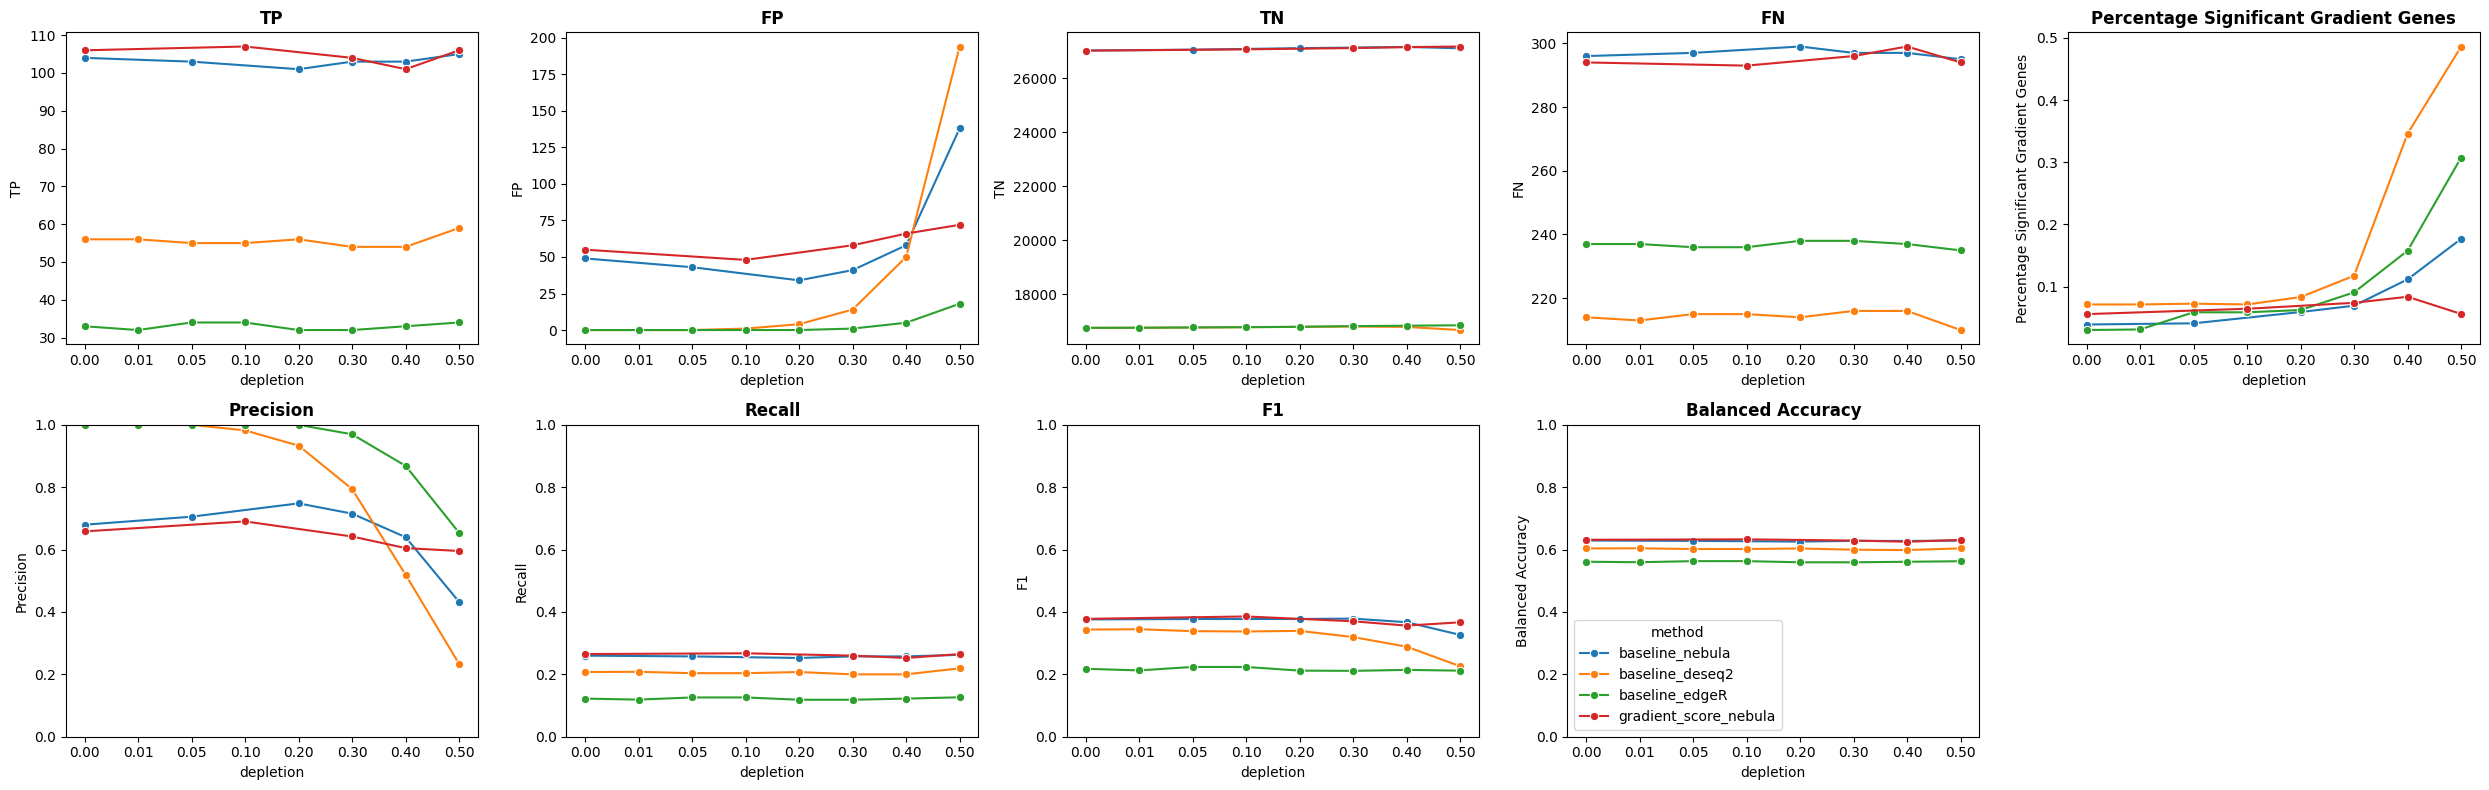

In [11]:
CONFUSION_METRICS = ["TP", "FP", "TN", "FN", "Percentage Significant Gradient Genes"]
PERFORMANCE_METRICS = ["Precision", "Recall", "F1", "Balanced Accuracy"]

fig, axes = plt.subplots(2, 5, figsize=(25, 8))  # Changed to 5 columns
axes = axes.flatten()

# Plot confusion matrix metrics (row 1)
for i, metric in enumerate(CONFUSION_METRICS):
    sns.lineplot(data=df_summary, x="depletion", y=metric, hue="method", ax=axes[i], marker='o')
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].get_legend().remove()

# Plot performance metrics (row 2)
for i, metric in enumerate(PERFORMANCE_METRICS):
    ax_idx = i + 5  # Changed from 4 to 5
    sns.lineplot(data=df_summary, x="depletion", y=metric, hue="method", ax=axes[ax_idx], marker='o')
    axes[ax_idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[ax_idx].set_ylim(0, 1)
    if i < len(PERFORMANCE_METRICS) - 1:
        axes[ax_idx].get_legend().remove()

# Hide the last subplot (bottom right, unused)
axes[-1].axis('off')

plt.tight_layout()
plt.show()